# Stage 7: Model Evaluation & Comparison

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, f1_score,
                              precision_recall_curve, average_precision_score,
                              accuracy_score, precision_score, recall_score)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

# Load test data and models
X_test        = pd.read_csv('./data/processed/X_test.csv')
X_test_scaled = pd.read_csv('./data/processed/X_test_scaled.csv')
y_test        = pd.read_csv('./data/processed/y_test.csv').squeeze()

best_rf  = joblib.load('./models/random_forest.pkl')
best_svm = joblib.load('./models/svm.pkl')
best_xgb = joblib.load('./models/xgboost.pkl')

models = {
    'Random Forest': (best_rf, X_test),
    'SVM':           (best_svm, X_test_scaled),
    'XGBoost':       (best_xgb, X_test)
}
print('All models and test data loaded ✓')

All models and test data loaded ✓


## 7.1 Classification Reports

In [2]:
results = {}

for name, (model, X_t) in models.items():
    y_pred  = model.predict(X_t)
    y_proba = model.predict_proba(X_t)[:, 1]
    
    results[name] = {
        'y_pred': y_pred, 'y_proba': y_proba,
        'accuracy':  accuracy_score(y_test, y_pred),
        'f1':        f1_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall':    recall_score(y_test, y_pred),
        'auc':       roc_auc_score(y_test, y_proba)
    }
    
    print(f'\n{'='*50}')
    print(f'  {name}')
    print(f'{'='*50}')
    print(classification_report(y_test, y_pred, target_names=['Non-Potable', 'Potable']))


  Random Forest
              precision    recall  f1-score   support

 Non-Potable       0.83      0.78      0.81       400
     Potable       0.69      0.75      0.72       256

    accuracy                           0.77       656
   macro avg       0.76      0.77      0.76       656
weighted avg       0.77      0.77      0.77       656


  SVM
              precision    recall  f1-score   support

 Non-Potable       0.68      0.68      0.68       400
     Potable       0.49      0.49      0.49       256

    accuracy                           0.60       656
   macro avg       0.58      0.58      0.58       656
weighted avg       0.60      0.60      0.60       656


  XGBoost
              precision    recall  f1-score   support

 Non-Potable       0.83      0.80      0.81       400
     Potable       0.71      0.74      0.72       256

    accuracy                           0.78       656
   macro avg       0.77      0.77      0.77       656
weighted avg       0.78      0.78      

## 7.2 Model Comparison Table

In [3]:
comparison_df = pd.DataFrame({
    name: {
        'Accuracy':  f"{r['accuracy']:.4f}",
        'F1-Score':  f"{r['f1']:.4f}",
        'Precision': f"{r['precision']:.4f}",
        'Recall':    f"{r['recall']:.4f}",
        'ROC-AUC':   f"{r['auc']:.4f}"
    } for name, r in results.items()
}).T

print('=== MODEL COMPARISON ===')
print(comparison_df.to_string())

# Highlight best model
best_model_name = max(results, key=lambda k: results[k]['auc'])
print(f'\n🏆 Best Model by AUC: {best_model_name} ({results[best_model_name]["auc"]:.4f})')

=== MODEL COMPARISON ===
              Accuracy F1-Score Precision  Recall ROC-AUC
Random Forest   0.7698   0.7178    0.6882  0.7500  0.8683
SVM             0.6037   0.4922    0.4922  0.4922  0.6164
XGBoost         0.7774   0.7214    0.7052  0.7383  0.8762

🏆 Best Model by AUC: XGBoost (0.8762)


## 7.3 Confusion Matrices

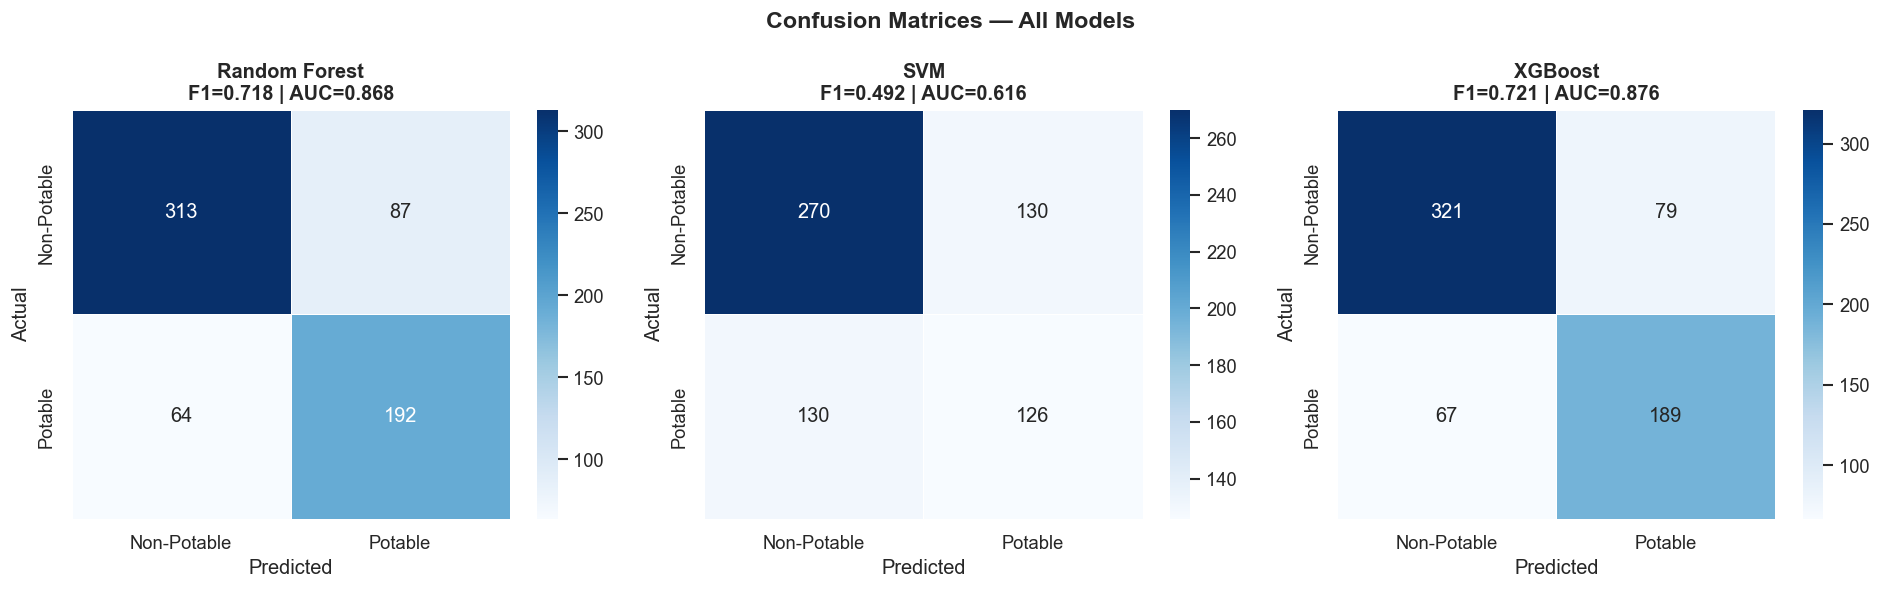

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non-Potable', 'Potable'],
                yticklabels=['Non-Potable', 'Potable'],
                linewidths=0.5)
    ax.set_title(f'{name}\nF1={r["f1"]:.3f} | AUC={r["auc"]:.3f}', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./data/processed/confusion_matrices.png', bbox_inches='tight', dpi=150)
plt.show()

## 7.4 ROC Curves

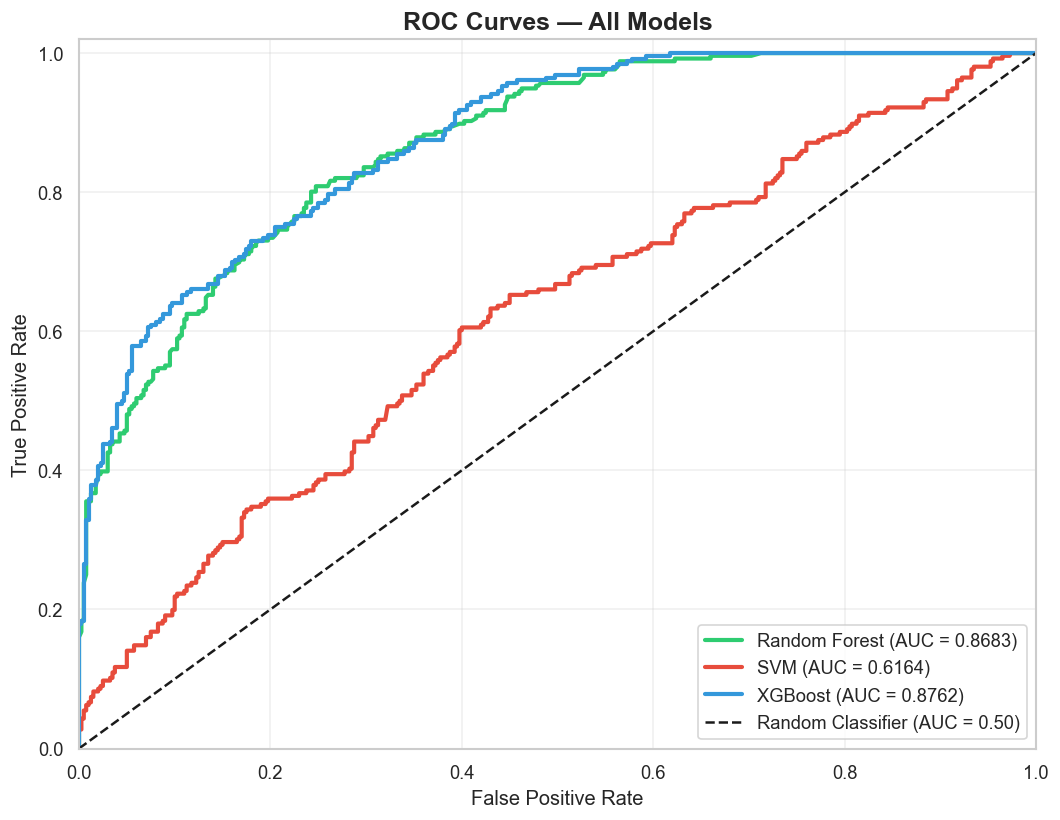

In [5]:
plt.figure(figsize=(9, 7))
colors = ['#2ecc71', '#e74c3c', '#3498db']

for (name, r), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    plt.plot(fpr, tpr, color=color, lw=2.5,
             label=f'{name} (AUC = {r["auc"]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.02])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Models', fontsize=15, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('./data/processed/roc_curves.png', bbox_inches='tight', dpi=150)
plt.show()

## 7.5 Precision-Recall Curves

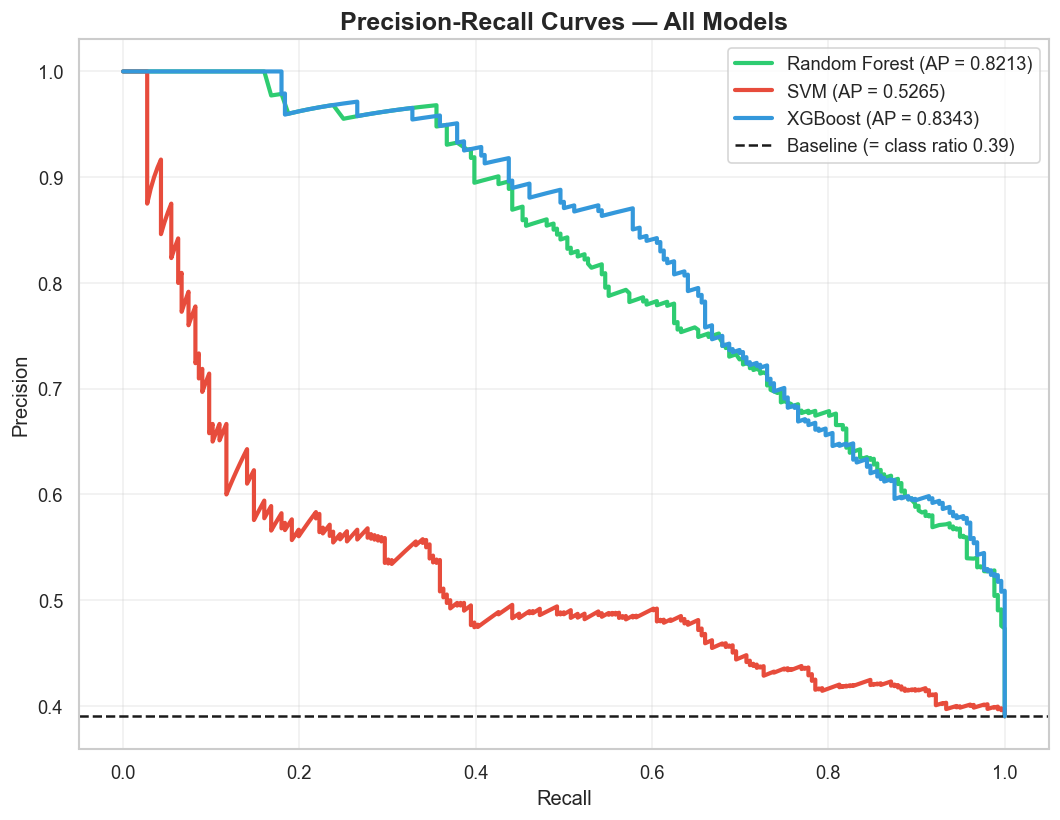

In [6]:
plt.figure(figsize=(9, 7))

for (name, r), color in zip(results.items(), colors):
    precision, recall, _ = precision_recall_curve(y_test, r['y_proba'])
    ap = average_precision_score(y_test, r['y_proba'])
    plt.plot(recall, precision, color=color, lw=2.5,
             label=f'{name} (AP = {ap:.4f})')

baseline = y_test.mean()
plt.axhline(baseline, color='k', linestyle='--', lw=1.5,
            label=f'Baseline (= class ratio {baseline:.2f})')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curves — All Models', fontsize=15, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('./data/processed/precision_recall_curves.png', bbox_inches='tight', dpi=150)
plt.show()

## 7.6 Threshold Analysis

In [7]:
from sklearn.metrics import precision_recall_curve, f1_score
import numpy as np

print('OPTIMAL THRESHOLD ANALYSIS\n')
print('='*70)
print('Finding thresholds that optimize both F1-Score and Cost')
print('='*70 + '\n')

# Cost-based threshold optimization
FN_COST = 5   # unsafe water classified as safe (health risk)
FP_COST = 1   # safe water classified as unsafe (unnecessary caution)

for name, (model, X_t) in models.items():
    proba = results[name]['y_proba']
    
    precisions, recalls, thresholds = precision_recall_curve(y_test, proba)
    
    # Fix F1 calculation: use proper formula
    # F1 = 2 * (precision * recall) / (precision + recall)
    f1s = np.zeros(len(precisions))
    for i in range(len(precisions)):
        denom = precisions[i] + recalls[i]
        f1s[i] = 2 * (precisions[i] * recalls[i]) / denom if denom > 0 else 0
    
    # Find threshold that maximizes F1
    best_f1_idx = np.argmax(f1s)
    best_f1_thresh = thresholds[best_f1_idx] if best_f1_idx < len(thresholds) else 0.5
    y_pred_f1 = (proba >= best_f1_thresh).astype(int)
    f1_opt = f1_score(y_test, y_pred_f1)
    
    # Find threshold that minimizes COST
    costs = []
    for thresh in thresholds:
        y_pred_cost = (proba >= thresh).astype(int)
        cm = confusion_matrix(y_test, y_pred_cost)
        tn, fp, fn, tp = cm.ravel()
        cost = fn * FN_COST + fp * FP_COST
        costs.append(cost)
    
    best_cost_idx = np.argmin(costs)
    best_cost_thresh = thresholds[best_cost_idx] if best_cost_idx < len(thresholds) else 0.5
    y_pred_cost = (proba >= best_cost_thresh).astype(int)
    f1_cost = f1_score(y_test, y_pred_cost)
    cm_cost = confusion_matrix(y_test, y_pred_cost)
    tn_c, fp_c, fn_c, tp_c = cm_cost.ravel()
    cost_val = fn_c * FN_COST + fp_c * FP_COST
    
    print(f'{name}')
    print(f'  Default threshold (0.50):')
    print(f'    F1-Score: {results[name]["f1"]:.4f}')
    print(f'  ')
    print(f'  F1-Optimized threshold ({best_f1_thresh:.3f}):')
    print(f'    F1-Score: {f1_opt:.4f}  |  Improvement: {f1_opt - results[name]["f1"]:+.4f}')
    print(f'  ')
    print(f'  Cost-Optimized threshold ({best_cost_thresh:.3f}) [FN={FN_COST}x, FP={FP_COST}x]:')
    print(f'    F1-Score: {f1_cost:.4f}  |  Weighted Cost: {cost_val}')
    print(f'    FN: {fn_c:3d}  |  FP: {fp_c:3d}')
    print(f'  → Cost-based threshold RECOMMENDED for production (minimizes health risk)\n')


OPTIMAL THRESHOLD ANALYSIS

Finding thresholds that optimize both F1-Score and Cost

Random Forest
  Default threshold (0.50):
    F1-Score: 0.7178
  
  F1-Optimized threshold (0.467):
    F1-Score: 0.7367  |  Improvement: +0.0189
  
  Cost-Optimized threshold (0.269) [FN=5x, FP=1x]:
    F1-Score: 0.6884  |  Weighted Cost: 241
    FN:   3  |  FP: 226
  → Cost-based threshold RECOMMENDED for production (minimizes health risk)

SVM
  Default threshold (0.50):
    F1-Score: 0.4922
  
  F1-Optimized threshold (0.190):
    F1-Score: 0.5718  |  Improvement: +0.0796
  
  Cost-Optimized threshold (0.063) [FN=5x, FP=1x]:
    F1-Score: 0.5683  |  Weighted Cost: 389
    FN:   0  |  FP: 389
  → Cost-based threshold RECOMMENDED for production (minimizes health risk)

XGBoost
  Default threshold (0.50):
    F1-Score: 0.7214
  
  F1-Optimized threshold (0.344):
    F1-Score: 0.7273  |  Improvement: +0.0059
  
  Cost-Optimized threshold (0.127) [FN=5x, FP=1x]:
    F1-Score: 0.7182  |  Weighted Cost: 2

## 7.7 False Negative Cost Analysis

In [8]:
print('FALSE NEGATIVE COST ANALYSIS')
print('='*70)
print('Context & Justification:')
print('  • False Negative = Model predicts UNSAFE water as SAFE')
print('    → Person drinks contaminated water → HEALTH RISK')
print('  • False Positive = Model predicts SAFE water as UNSAFE')
print('    → Unnecessary caution, waste of resources, but no health risk')
print('')
print('Cost Ratio Justification:')
print('  • FN_COST = 5: Health/safety is paramount in water quality classification.')
print('    Missing contaminated water can cause illness, so cost is HIGH.')
print('  • FP_COST = 1: False alarms are inconvenient but not dangerous.')
print('    Treating safe water as unsafe has minimal negative impact.')
print('  • Ratio (5:1) aligns with regulatory standards: safety > convenience')
print('='*70 + '\n')

# Use same cost ratio as in threshold optimization
FN_COST = 5   # unsafe water classified as safe
FP_COST = 1   # safe water classified as unsafe (unnecessary caution)

print(f'{"Model":<18} {"FN":>6} {"FP":>6} {"Total Errors":>14} {"Weighted Cost":>15}')
print('─' * 65)

for name, r in results.items():
    cm = confusion_matrix(y_test, r['y_pred'])
    tn, fp, fn, tp = cm.ravel()
    cost = fn * FN_COST + fp * FP_COST
    print(f'{name:<18} {fn:>6} {fp:>6} {fn+fp:>14} {cost:>15}')

print(f'\nCost Weights: FN = {FN_COST}x (health risk) | FP = {FP_COST}x (inconvenience)')
print('→ Lower weighted cost = Better model for water safety')


FALSE NEGATIVE COST ANALYSIS
Context & Justification:
  • False Negative = Model predicts UNSAFE water as SAFE
    → Person drinks contaminated water → HEALTH RISK
  • False Positive = Model predicts SAFE water as UNSAFE
    → Unnecessary caution, waste of resources, but no health risk

Cost Ratio Justification:
  • FN_COST = 5: Health/safety is paramount in water quality classification.
    Missing contaminated water can cause illness, so cost is HIGH.
  • FP_COST = 1: False alarms are inconvenient but not dangerous.
    Treating safe water as unsafe has minimal negative impact.
  • Ratio (5:1) aligns with regulatory standards: safety > convenience

Model                  FN     FP   Total Errors   Weighted Cost
─────────────────────────────────────────────────────────────────
Random Forest          64     87            151             407
SVM                   130    130            260             780
XGBoost                67     79            146             414

Cost Weights: FN =

## 7.8 Feature Importance Analysis

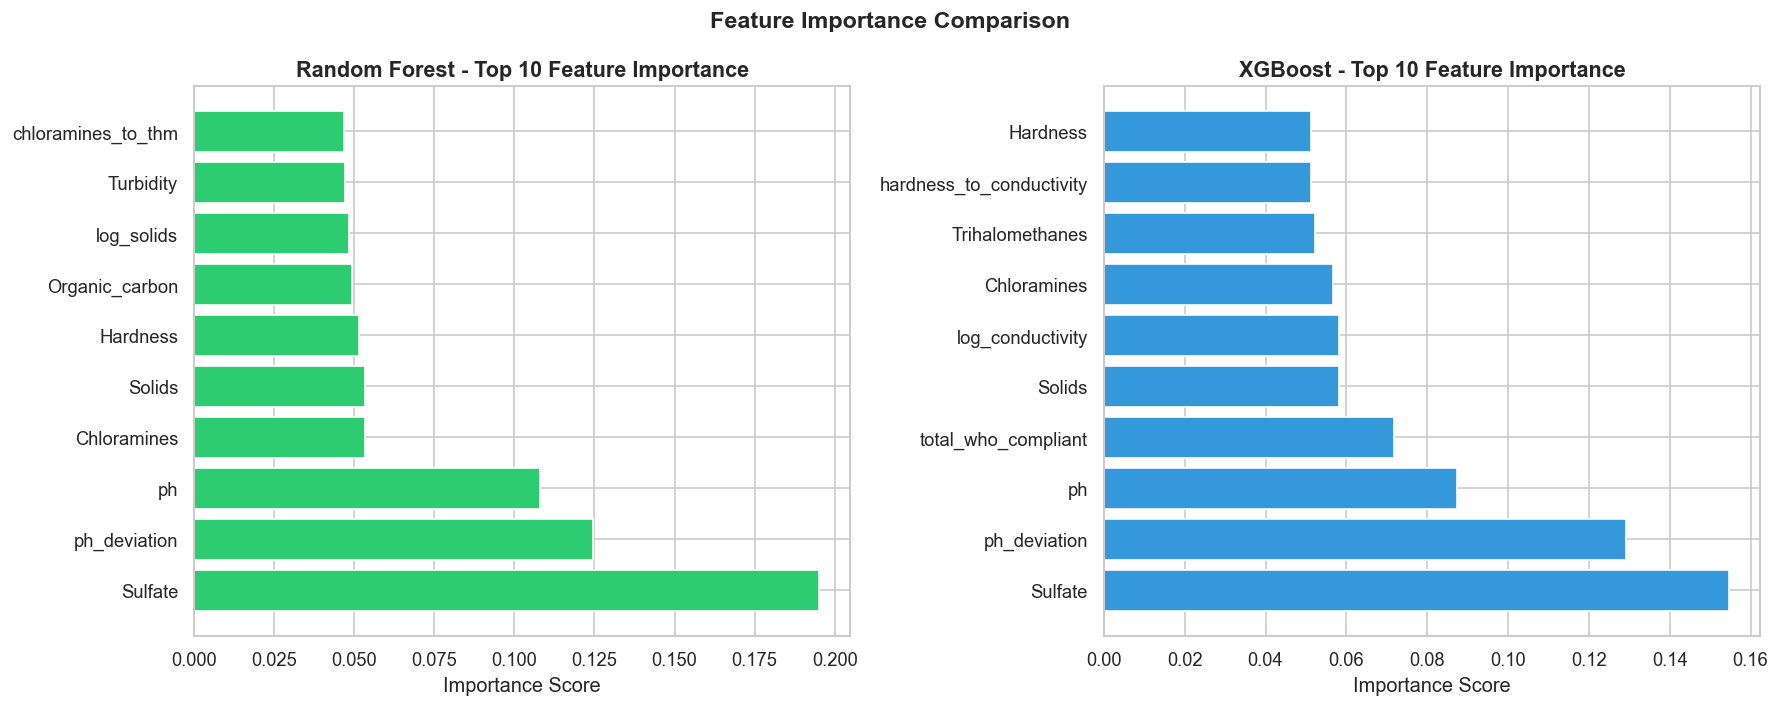

✓ Feature importance visualizations saved


In [9]:
# Feature Importance for Random Forest and XGBoost
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Random Forest Feature Importance
rf_importances = best_rf.feature_importances_
rf_indices = np.argsort(rf_importances)[-10:]  # Top 10
feature_names = X_test.columns[rf_indices]

axes[0].barh(range(len(rf_indices)), rf_importances[rf_indices], color='#2ecc71')
axes[0].set_yticks(range(len(rf_indices)))
axes[0].set_yticklabels(feature_names)
axes[0].set_xlabel('Importance Score', fontsize=12)
axes[0].set_title('Random Forest - Top 10 Feature Importance', fontweight='bold', fontsize=13)
axes[0].invert_yaxis()

# XGBoost Feature Importance
xgb_importances = best_xgb.feature_importances_
xgb_indices = np.argsort(xgb_importances)[-10:]  # Top 10
feature_names_xgb = X_test.columns[xgb_indices]

axes[1].barh(range(len(xgb_indices)), xgb_importances[xgb_indices], color='#3498db')
axes[1].set_yticks(range(len(xgb_indices)))
axes[1].set_yticklabels(feature_names_xgb)
axes[1].set_xlabel('Importance Score', fontsize=12)
axes[1].set_title('XGBoost - Top 10 Feature Importance', fontweight='bold', fontsize=13)
axes[1].invert_yaxis()

plt.suptitle('Feature Importance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./data/processed/feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()

print('✓ Feature importance visualizations saved')


## 7.9 Prediction Confidence Distribution

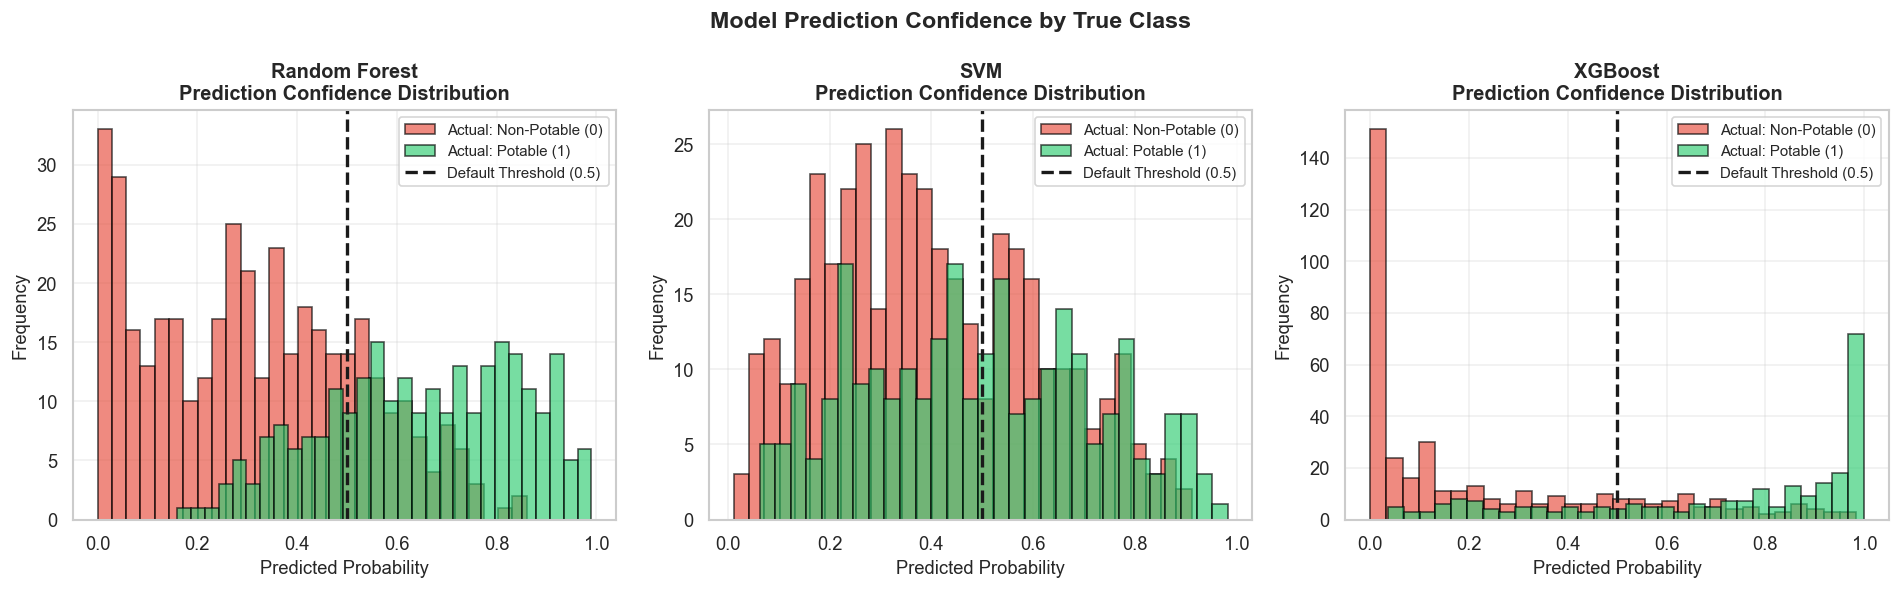

✓ Prediction confidence distributions saved

Interpretation:
  • Well-separated histograms → Good model calibration
  • Overlapping histograms → Model less confident in distinguishing classes
  • Skewed distributions → May indicate class imbalance or poor calibration


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, r) in zip(axes, results.items()):
    proba = r['y_proba']
    
    # Separate probabilities by actual class
    proba_unsafe = proba[y_test == 0]
    proba_safe = proba[y_test == 1]
    
    ax.hist(proba_unsafe, bins=30, alpha=0.65, label='Actual: Non-Potable (0)', 
            color='#e74c3c', edgecolor='black')
    ax.hist(proba_safe, bins=30, alpha=0.65, label='Actual: Potable (1)', 
            color='#2ecc71', edgecolor='black')
    
    ax.axvline(0.5, color='k', linestyle='--', linewidth=2, label='Default Threshold (0.5)')
    ax.set_xlabel('Predicted Probability', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.set_title(f'{name}\nPrediction Confidence Distribution', fontweight='bold', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Model Prediction Confidence by True Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./data/processed/prediction_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

print('✓ Prediction confidence distributions saved')
print('\nInterpretation:')
print('  • Well-separated histograms → Good model calibration')
print('  • Overlapping histograms → Model less confident in distinguishing classes')
print('  • Skewed distributions → May indicate class imbalance or poor calibration')


## 7.10 Save Best Model

In [11]:
# Save best model as the production model
best_model_name = max(results, key=lambda k: results[k]['auc'])
best_model_obj, _ = models[best_model_name]

joblib.dump(best_model_obj, './models/best_model.pkl')
joblib.dump(best_model_name, './models/best_model_name.pkl')

print(f'✓ Best model ({best_model_name}) saved as models/best_model.pkl')
print(f'  Accuracy: {results[best_model_name]["accuracy"]:.4f}')
print(f'  F1-Score: {results[best_model_name]["f1"]:.4f}')
print(f'  ROC-AUC:  {results[best_model_name]["auc"]:.4f}')

✓ Best model (XGBoost) saved as models/best_model.pkl
  Accuracy: 0.7774
  F1-Score: 0.7214
  ROC-AUC:  0.8762
